In [5]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

In [8]:
# load the data
train = pd.read_csv("/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/data/train.csv")
test =  pd.read_csv("/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/data/test.csv")

In [9]:

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (6818, 13)
Test shape: (1705, 12)


In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   str    
 1   product_code         6818 non-null   str    
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   str    
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   str    
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   str    
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   str    
 10  store_location_tier  6818 non-null   str    
 11  store_format         6818 non-null   str    
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 692.6 KB


In [11]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1705 non-null   str    
 1   product_code         1705 non-null   str    
 2   product_weight_kg    1399 non-null   float64
 3   fat_content          1705 non-null   str    
 4   shelf_visibility     1705 non-null   float64
 5   product_category     1705 non-null   str    
 6   product_price        1705 non-null   float64
 7   store_code           1705 non-null   str    
 8   store_age_years      1705 non-null   int64  
 9   store_size           1214 non-null   str    
 10  store_location_tier  1705 non-null   str    
 11  store_format         1705 non-null   str    
dtypes: float64(3), int64(1), str(8)
memory usage: 160.0 KB


In [15]:
train.isnull().sum() * 0.01

id                      0.00
product_code            0.00
product_weight_kg      12.25
fat_content             0.00
shelf_visibility        0.00
product_category        0.00
product_price           0.00
store_code              0.00
store_age_years         0.00
store_size             19.19
store_location_tier     0.00
store_format            0.00
total_sales             0.00
dtype: float64

In [16]:
test.isnull().sum() * 0.01

id                     0.00
product_code           0.00
product_weight_kg      3.06
fat_content            0.00
shelf_visibility       0.00
product_category       0.00
product_price          0.00
store_code             0.00
store_age_years        0.00
store_size             4.91
store_location_tier    0.00
store_format           0.00
dtype: float64

In [ ]:
# fix missing values
# Missing in product_weight_kg (17.97%) → impute with median
imputer_weight = SimpleImputer(strategy='median')
train['product_weight_kg'] = imputer_weight.fit_transform(train[['product_weight_kg']])
test['product_weight_kg'] = imputer_weight.transform(test[['product_weight_kg']])


# Verify no more missing
print("Missing values after imputation:")
print(train.isnull().sum())
print("test data:")
print(test.isnull().sum())

Missing values after imputation:
id                        0
product_code              0
product_weight_kg         0
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64
test data:
id                       0
product_code             0
product_weight_kg        0
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64


In [32]:
# Missing in store_size (28.15%) → impute with mode (most frequent)
imputer_size = SimpleImputer(strategy='most_frequent')
train['store_size'] = imputer_size.fit_transform(train[['store_size']]).ravel()
test['store_size'] = imputer_size.transform(test[['store_size']]).ravel()

# check
print(train.isnull().sum())
print(test.isnull().sum())

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64
id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
dtype: int64


In [34]:
train["product_category"].unique()

<StringArray>
[         'Frozen Foods',    'HEALTH AND HYGIENE',                'Canned',
           'soft drinks',                  'meat',           'Snack Foods',
          'baking goods',             'household',             'Household',
                 'Dairy',                 'dairy',                'CANNED',
           'SNACK FOODS',             'HOUSEHOLD',           'Soft Drinks',
 'Fruits and Vegetables',             'Breakfast',                'Breads',
                  'Meat',          'BAKING GOODS',                'canned',
                 'DAIRY',             'breakfast',          'Baking Goods',
    'Health and Hygiene',                  'MEAT',               'Seafood',
 'fruits and vegetables',          'frozen foods',           'snack foods',
          'FROZEN FOODS',                'Others', 'FRUITS AND VEGETABLES',
    'health and hygiene',                'OTHERS',                'BREADS',
               'SEAFOOD',           'SOFT DRINKS',           'Hard Drinks'

In [35]:
# standardize product category
# Convert all product categories to lowercase for consistency
train['product_category'] = train['product_category'].str.lower().str.strip()
test['product_category'] = test['product_category'].str.lower().str.strip()

# Check unique categories after standardization
print("Unique product categories:", train['product_category'].nunique())
print(train['product_category'].unique())

Unique product categories: 16
<StringArray>
[         'frozen foods',    'health and hygiene',                'canned',
           'soft drinks',                  'meat',           'snack foods',
          'baking goods',             'household',                 'dairy',
 'fruits and vegetables',             'breakfast',                'breads',
               'seafood',                'others',           'hard drinks',
         'starchy foods']
Length: 16, dtype: str


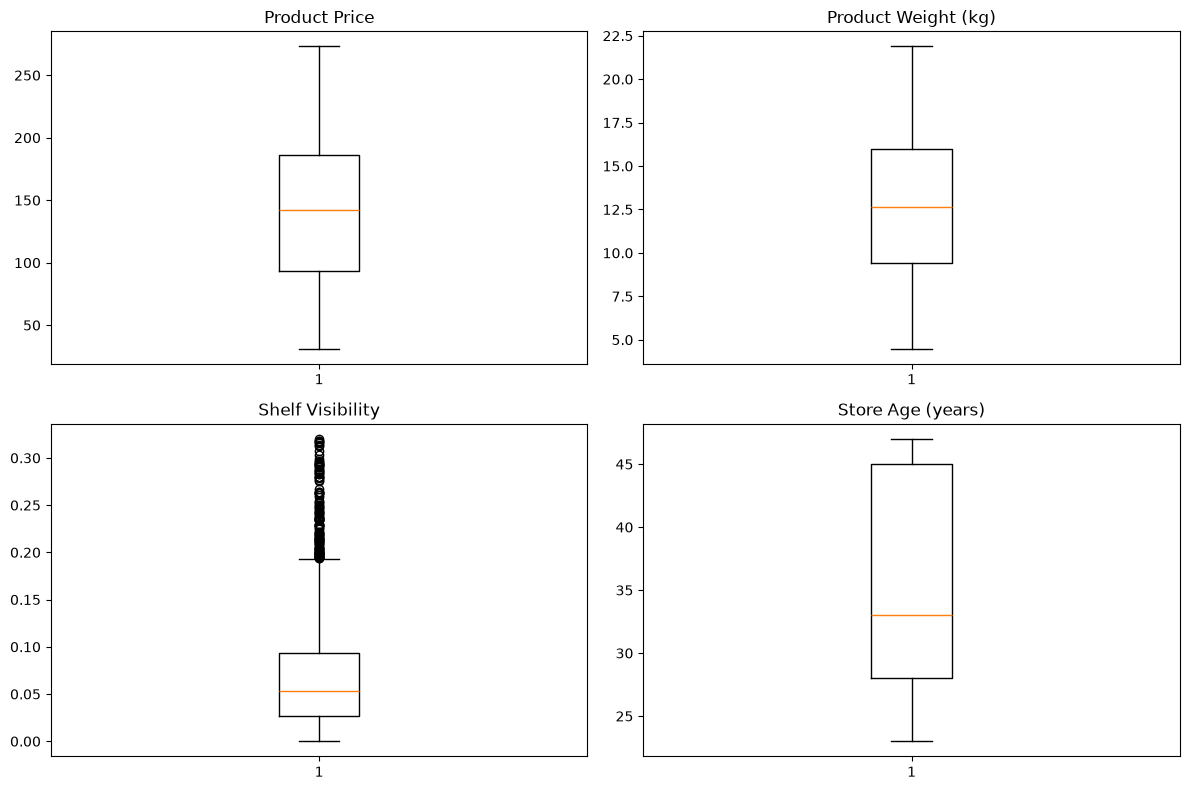

       product_price  product_weight_kg  shelf_visibility  store_age_years
count    6818.000000        6818.000000       6818.000000      6818.000000
mean      140.473623          12.814245          0.065527        34.178205
std        62.413513           4.209126          0.051566         8.384574
min        31.110000           4.482000          0.000000        23.000000
25%        93.280000           9.438000          0.026600        28.000000
50%       142.065000          12.647000          0.053200        33.000000
75%       185.987500          15.953750          0.093400        45.000000
max       273.040000          21.883000          0.320100        47.000000


In [36]:
# check for outlier
import matplotlib.pyplot as plt

# Visualize numerical distributions for outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].boxplot(train['product_price'])
axes[0, 0].set_title('Product Price')

axes[0, 1].boxplot(train['product_weight_kg'])
axes[0, 1].set_title('Product Weight (kg)')

axes[1, 0].boxplot(train['shelf_visibility'])
axes[1, 0].set_title('Shelf Visibility')

axes[1, 1].boxplot(train['store_age_years'])
axes[1, 1].set_title('Store Age (years)')

plt.tight_layout()
plt.show()

# Summary stats to check for extreme values
print(train[['product_price', 'product_weight_kg', 'shelf_visibility', 'store_age_years']].describe())

Shelf Visibility Statistics:
count    6818.000000
mean        0.065527
std         0.051566
min         0.000000
25%         0.026600
50%         0.053200
75%         0.093400
max         0.320100
Name: shelf_visibility, dtype: float64


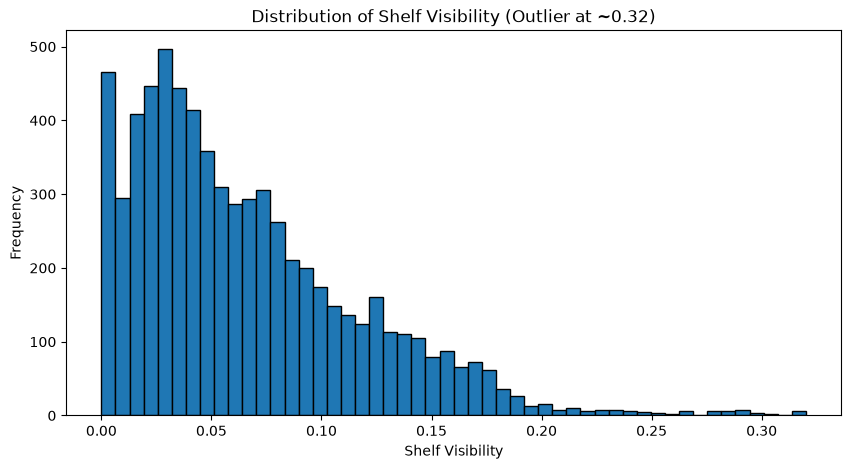

Values > 0.3: 9
Values in [0.28-0.32]: 26


In [39]:
# Check shelf_visibility outliers
print("Shelf Visibility Statistics:")
print(train['shelf_visibility'].describe())

# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(train['shelf_visibility'], bins=50, edgecolor='black')
plt.xlabel('Shelf Visibility')
plt.ylabel('Frequency')
plt.title('Distribution of Shelf Visibility (Outlier at ~0.32)')
plt.show()

# Count extreme values
print(f"Values > 0.3: {(train['shelf_visibility'] > 0.3).sum()}")
print(f"Values in [0.28-0.32]: {((train['shelf_visibility'] >= 0.28) & (train['shelf_visibility'] <= 0.32)).sum()}")

In [38]:
print("\n=== CLEANED DATA SUMMARY ===")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Missing values: {train.isnull().sum().sum()}")
print(f"Duplicates: {train.duplicated().sum()}")
print("\nCleaned training data ready for feature engineering!")


=== CLEANED DATA SUMMARY ===
Train shape: (6818, 13)
Test shape: (1705, 12)
Missing values: 0
Duplicates: 0

Cleaned training data ready for feature engineering!


In [40]:
# Save cleaned data
train.to_csv('/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/data/train_cleaned.csv', index=False)
test.to_csv('/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/data/test_cleaned.csv', index=False)